# Simulação

Implementar computacionalmente o exemplo desenvolvido na seção anterior, utilizando **GNU Octave ou Python**.

A implementação deve reproduzir, de forma computacional, as etapas matemáticas apresentadas anteriormente, permitindo verificar os resultados obtidos e, quando pertinente, analisar o comportamento do sistema para diferentes condições de entrada.

## Implementação

Apresentar o código-fonte utilizado na simulação.

**Código da simulação:**

In [4]:
# ============================================================
# Importações
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
# ============================================================
# CONFIGURAÇÃO VISUAL
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

In [6]:
# ============================================================
# PARÂMETROS DO SINAL
# ============================================================

A = 1.0          # Amplitude
f0 = 5.0         # Frequência do sinal (Hz)
phi = 0.0        # Fase inicial (rad)
T = 1.0          # Duração da simulação (s)

# Frequências de amostragem analisadas
fs_values = [20, 10, 6]

In [9]:
# ============================================================
# SINAL CONTÍNUO
# ============================================================

# Malha temporal densa para representar o sinal contínuo
t = np.linspace(0, T, 5000)

# Equação do sinal senoidal
x = A * np.sin(2 * np.pi * f0 * t + phi)

# ============================================================
# INFORMAÇÕES SOBRE O SINAL
# ============================================================

periodo_sinal = 1 / f0

print("=" * 60)
print("INFORMAÇÕES DO SINAL")
print("=" * 60)
print(f"Amplitude:              {A:.2f}")
print(f"Frequência:             {f0:.2f} Hz")
print(f"Período:                {periodo_sinal:.4f} s")
print(f"Duração da simulação:  {T:.2f} s")
print(f"Limite de Nyquist:      {2 * f0:.2f} Hz")
print("=" * 60)

INFORMAÇÕES DO SINAL
Amplitude:              1.00
Frequência:             5.00 Hz
Período:                0.2000 s
Duração da simulação:  1.00 s
Limite de Nyquist:      10.00 Hz


In [15]:
# ============================================================
# SIMULAÇÃO PARA CADA FREQUÊNCIA
# ============================================================

resultados = []

for fs in fs_values:

    # Período de amostragem
    Ts = 1 / fs

    # Instantes das amostras
    tn = np.arange(0, T + Ts, Ts)

    # Valores amostrados
    xn = A * np.sin(2 * np.pi * f0 * tn + phi)

    # Número aproximado de amostras por ciclo
    amostras_por_ciclo = fs / f0

    # Verificação da condição de Nyquist
    if fs > 2 * f0:
        situacao = "Adequada"
    elif fs == 2 * f0:
        situacao = "Limite de Nyquist"
    else:
        situacao = "Subamostragem"

    # Frequência de alias teórica
    # Frequência observada no domínio discreto
    alias_freq = abs(f0 - round(f0 / fs) * fs)

    resultados.append({
        "fs (Hz)": fs,
        "Ts (s)": Ts,
        "Amostras": len(tn),
        "Amostras/ciclo": amostras_por_ciclo,
        "Alias (Hz)": alias_freq,
        "Situação": situacao
    })

# ============================================================
# TABELA DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame(resultados)

print("\n")
print("=" * 80)
print("RESULTADOS DA AMOSTRAGEM")
print("=" * 80)

print(
    df_resultados.to_string(
        index=False,
        formatters={
            "Ts (s)": "{:.4f}".format,
            "Amostras/ciclo": "{:.2f}".format,
            "Alias (Hz)": "{:.2f}".format
        }
    )
)




RESULTADOS DA AMOSTRAGEM
 fs (Hz) Ts (s)  Amostras Amostras/ciclo Alias (Hz)          Situação
      20 0.0500        21           4.00       5.00          Adequada
      10 0.1000        11           2.00       5.00 Limite de Nyquist
       6 0.1667         8           1.20       1.00     Subamostragem


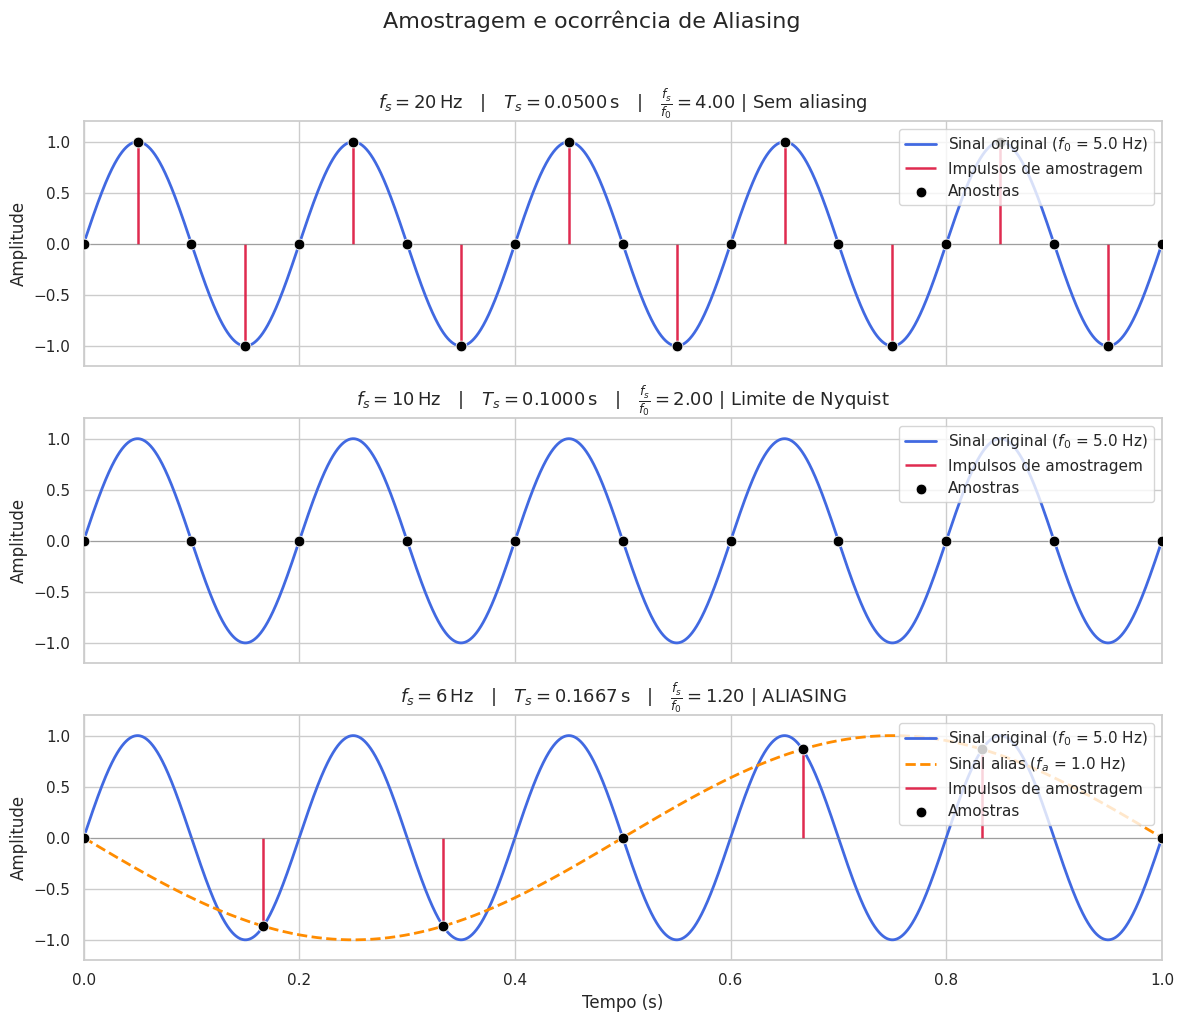

In [18]:
## ============================================================
# CONFIGURAÇÃO DO MATPLOTLIB
# ============================================================

plt.rcParams["text.usetex"] = False
plt.rcParams["text.parse_math"] = True


# ============================================================
# COMPARAÇÃO DAS TRÊS FREQUÊNCIAS DE AMOSTRAGEM
# COM REPRESENTAÇÃO CORRETA DO ALIASING
# ============================================================

fig, axes = plt.subplots(
    len(fs_values),
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, fs in zip(axes, fs_values):

    # --------------------------------------------------------
    # Período de amostragem
    # --------------------------------------------------------

    Ts = 1 / fs

    # Instantes das amostras
    tn = np.arange(0, T + Ts, Ts)

    # Valores amostrados
    xn = A * np.sin(
        2 * np.pi * f0 * tn + phi
    )

    # --------------------------------------------------------
    # Frequência alias
    # --------------------------------------------------------

    f_alias = f0 - round(f0 / fs) * fs

    # --------------------------------------------------------
    # Sinal contínuo original
    # --------------------------------------------------------

    sns.lineplot(
        x=t,
        y=x,
        ax=ax,
        color="royalblue",
        linewidth=2,
        label=rf"Sinal original ($f_0$ = {f0} Hz)"
    )

    # --------------------------------------------------------
    # Sinal alias
    # --------------------------------------------------------

    x_alias = A * np.sin(
        2 * np.pi * f_alias * t + phi
    )

    if not np.isclose(abs(f_alias), f0):

        sns.lineplot(
            x=t,
            y=x_alias,
            ax=ax,
            color="darkorange",
            linestyle="--",
            linewidth=2,
            label=rf"Sinal alias ($f_a$ = {abs(f_alias):.1f} Hz)"
        )

    # --------------------------------------------------------
    # Impulsos de amostragem
    # --------------------------------------------------------

    ax.vlines(
        tn,
        0,
        xn,
        color="crimson",
        linewidth=1.8,
        alpha=0.9,
        label="Impulsos de amostragem"
    )

    # --------------------------------------------------------
    # Pontos das amostras
    # --------------------------------------------------------

    sns.scatterplot(
        x=tn,
        y=xn,
        ax=ax,
        color="black",
        s=60,
        zorder=3,
        label="Amostras"
    )

    # --------------------------------------------------------
    # Eixo horizontal
    # --------------------------------------------------------

    ax.axhline(
        0,
        color="gray",
        linewidth=0.8,
        alpha=0.6
    )

    # --------------------------------------------------------
    # Classificação
    # --------------------------------------------------------

    if fs > 2 * f0:

        situacao = "Sem aliasing"

    elif np.isclose(fs, 2 * f0):

        situacao = "Limite de Nyquist"

    else:

        situacao = "ALIASING"

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax.set_title(
        rf"$f_s = {fs}\,\mathrm{{Hz}}"
        rf"\quad|\quad"
        rf"T_s = {Ts:.4f}\,\mathrm{{s}}"
        rf"\quad|\quad"
        rf"\frac{{f_s}}{{f_0}} = {fs / f0:.2f}$"
        f" | {situacao}",
        fontsize=13
    )

    ax.set_ylabel("Amplitude")
    ax.set_ylim(-1.2, 1.2)

    ax.legend(
        loc="upper right"
    )


# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

axes[-1].set_xlabel("Tempo (s)")

fig.suptitle(
    "Amostragem e ocorrência de Aliasing",
    fontsize=16,
    y=1.02
)

plt.xlim(0, T)

plt.tight_layout()

plt.show()